In [28]:
import ast
import statistics
import tokenize
import warnings
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

from src.config import FEATURES_CSV, METADATA_CSV, RAW_AI_DIR, RAW_HUMAN_DIR, REPORTS_DIR

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

In [35]:
def list_raw_files():
    rows = []
    for label, directory in (("human", RAW_HUMAN_DIR), ("ai", RAW_AI_DIR)):
        for path in sorted(directory.glob("*.py")):
            rows.append({"file": path.name, "label": label, "path": path})
    return pd.DataFrame(rows)

raw = list_raw_files()
if raw.empty:
    raise SystemExit("Нет данных в data/raw. Сначала запустите сборщики из src.collect.")

meta = pd.read_csv(METADATA_CSV) if METADATA_CSV.exists() else pd.DataFrame()
print(f"Всего файлов: {len(raw)}")
print(raw["label"].value_counts().to_string())

Всего файлов: 2249
label
human    1134
ai       1115


In [36]:
_BRANCH_NODES = (ast.If, ast.For, ast.While, ast.Try, ast.ExceptHandler, ast.With)


def _safe_mean(values):
    return statistics.fmean(values) if values else 0.0


def _node_lines(node):
    start, end = getattr(node, "lineno", None), getattr(node, "end_lineno", None)
    return (end - start + 1) if (start and end) else 0


def _max_depth(node, depth=0):
    best = depth
    for child in ast.iter_child_nodes(node):
        nxt = depth + 1 if isinstance(child, _BRANCH_NODES) else depth
        best = max(best, _max_depth(child, nxt))
    return best


def _ast_features(tree):
    funcs = [n for n in ast.walk(tree) if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef))]
    classes = [n for n in ast.walk(tree) if isinstance(n, ast.ClassDef)]
    imports = [n for n in ast.walk(tree) if isinstance(n, (ast.Import, ast.ImportFrom))]

    func_lengths = [_node_lines(f) for f in funcs]
    total_args = sum(len(f.args.args) for f in funcs)
    annotated_args = sum(1 for f in funcs for a in f.args.args if a.annotation is not None)
    annotated_returns = sum(1 for f in funcs if f.returns is not None)
    hint_denom = total_args + len(funcs)

    documentable = funcs + classes
    with_doc = [d for d in documentable if ast.get_docstring(d)]
    doc_lengths = [len(ast.get_docstring(d) or "") for d in with_doc]

    complexity = sum(1 for n in ast.walk(tree) if isinstance(n, _BRANCH_NODES))
    complexity += sum(len(n.values) - 1 for n in ast.walk(tree) if isinstance(n, ast.BoolOp))

    has_main = any(
        isinstance(n, ast.If) and isinstance(n.test, ast.Compare)
        and isinstance(n.test.left, ast.Name) and n.test.left.id == "__name__"
        for n in ast.walk(tree)
    )
    return {
        "num_functions": len(funcs),
        "num_classes": len(classes),
        "num_imports": len(imports),
        "func_len_mean": _safe_mean(func_lengths),
        "func_len_median": statistics.median(func_lengths) if func_lengths else 0.0,
        "func_len_max": max(func_lengths) if func_lengths else 0,
        "args_per_func_mean": _safe_mean([len(f.args.args) for f in funcs]),
        "max_nesting_depth": _max_depth(tree),
        "type_hint_coverage": (annotated_args + annotated_returns) / hint_denom if hint_denom else 0.0,
        "docstring_coverage": len(with_doc) / len(documentable) if documentable else 0.0,
        "docstring_len_mean": _safe_mean(doc_lengths),
        "cyclomatic_complexity": complexity,
        "has_main_guard": int(has_main),
    }


def _identifier_style(tree):
    names = [n.id for n in ast.walk(tree) if isinstance(n, ast.Name)]
    names += [f.name for f in ast.walk(tree)
              if isinstance(f, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef))]
    multiword = [n for n in names if len(n) > 1 and not n.isupper()]
    snake = sum(1 for n in multiword if "_" in n)
    camel = sum(1 for n in multiword if "_" not in n and any(c.isupper() for c in n[1:]))
    denom = snake + camel
    return {
        "snake_case_ratio": snake / denom if denom else 0.0,
        "camel_case_ratio": camel / denom if denom else 0.0,
        "identifier_len_mean": _safe_mean([len(n) for n in names]),
    }


def _lexical_features(source):
    lines = source.splitlines()
    n_lines = len(lines) or 1
    blank = sum(1 for ln in lines if not ln.strip())
    trailing_ws = sum(1 for ln in lines if ln != ln.rstrip())
    line_lengths = [len(ln) for ln in lines]

    comment_count = comment_chars = todo_count = 0
    indent_tab = indent_space = 0
    try:
        for tok in tokenize.generate_tokens(StringIO(source).readline):
            if tok.type == tokenize.COMMENT:
                comment_count += 1
                comment_chars += len(tok.string.lstrip("#").strip())
                up = tok.string.upper()
                todo_count += up.count("TODO") + up.count("FIXME")
            elif tok.type == tokenize.INDENT:
                if "\t" in tok.string:
                    indent_tab += 1
                else:
                    indent_space += 1
    except (tokenize.TokenError, IndentationError):
        pass

    code_lines = n_lines - blank
    return {
        "total_lines": n_lines,
        "blank_line_ratio": blank / n_lines,
        "comment_count": comment_count,
        "comment_to_code_ratio": comment_count / code_lines if code_lines else 0.0,
        "comment_len_mean": comment_chars / comment_count if comment_count else 0.0,
        "line_len_mean": _safe_mean(line_lengths),
        "line_len_max": max(line_lengths) if line_lengths else 0,
        "trailing_ws_ratio": trailing_ws / n_lines,
        "indent_tab_ratio": indent_tab / (indent_tab + indent_space) if (indent_tab + indent_space) else 0.0,
        "todo_count": todo_count,
    }


def extract_features(source):
    try:
        tree = ast.parse(source)
    except (SyntaxError, ValueError):
        return None
    feats = {}
    feats.update(_ast_features(tree))
    feats.update(_identifier_style(tree))
    feats.update(_lexical_features(source))
    return feats

In [37]:
records = []
for row in raw.itertuples(index=False):
    source = row.path.read_text(encoding="utf-8", errors="ignore")
    feats = extract_features(source)
    if feats is None:
        continue
    feats["label"] = row.label
    feats["file"] = row.file
    records.append(feats)

df = pd.DataFrame(records)
df.to_csv(FEATURES_CSV, index=False)

NON_FEATURE = ["label", "file"]
feature_cols = [c for c in df.columns if c not in NON_FEATURE]
print(f"Объектов: {len(df)} | признаков: {len(feature_cols)}")
df.head(n=100)

Объектов: 2249 | признаков: 26


,num_functions,num_classes,num_imports,func_len_mean,func_len_median,func_len_max,args_per_func_mean,max_nesting_depth,type_hint_coverage,docstring_coverage,docstring_len_mean,cyclomatic_complexity,has_main_guard,snake_case_ratio,camel_case_ratio,identifier_len_mean,total_lines,blank_line_ratio,comment_count,comment_to_code_ratio,comment_len_mean,line_len_mean,line_len_max,trailing_ws_ratio,indent_tab_ratio,todo_count,label,file
0,5,1,4,17.200000,19.0,25,1.800000,5,0.0,0.000000,0.000000,7,0,0.983051,0.016949,5.633663,97,0.061856,1,0.010989,40.000000,47.206186,116,0.000000,0.0,0,human,human_000b3df33bb0da94.py
1,7,0,9,14.285714,15.0,27,2.000000,2,0.0,1.000000,189.285714,10,0,1.000000,0.000000,9.359551,164,0.213415,21,0.162791,48.904762,32.018293,80,0.000000,0.0,1,human,human_002971e5a8433111.py
2,0,0,7,0.000000,0.0,0,0.000000,2,0.0,0.000000,0.000000,2,1,1.000000,0.000000,7.164835,63,0.238095,8,0.166667,16.625000,29.793651,94,0.000000,0.0,0,human,human_00502e5f49cea589.py
3,4,1,3,31.500000,37.0,47,6.000000,1,0.0,0.200000,29.000000,5,0,0.910714,0.089286,6.367816,170,0.117647,3,0.020000,42.666667,32.988235,168,0.011765,0.0,0,human,human_005279a655f0c8ff.py
4,7,2,4,9.142857,9.0,19,0.714286,2,0.0,0.222222,36.000000,6,0,0.962963,0.037037,6.816092,61,0.295082,1,0.023256,30.000000,30.622951,101,0.000000,0.0,0,human,human_0066d347e0ac4533.py
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,0,5,37.000000,26.0,64,0.600000,6,0.0,0.200000,47.000000,47,1,0.855263,0.144737,7.157895,237,0.126582,11,0.053140,8.909091,38.291139,153,0.008439,0.0,0,human,human_1364ac606d834adb.py
96,5,1,24,24.000000,26.0,36,1.800000,3,0.0,0.000000,0.000000,17,0,0.675000,0.325000,7.226415,173,0.196532,3,0.021583,33.666667,31.000000,112,0.000000,0.0,0,human,human_139286ddefe105ef.py
97,1,0,4,32.000000,32.0,32,3.000000,3,0.0,0.000000,0.000000,3,0,1.000000,0.000000,2.981481,38,0.263158,6,0.214286,34.500000,30.052632,84,0.000000,0.0,0,human,human_139faa0a2349840c.py
98,2,1,3,7.500000,7.5,13,3.500000,3,0.0,0.333333,60.000000,7,0,0.400000,0.600000,4.800000,26,0.153846,1,0.045455,3.000000,31.769231,88,0.000000,0.0,0,human,human_13af77507db04375.py


In [38]:
df[df['label'] == 'ai'].head()

,num_functions,num_classes,num_imports,func_len_mean,func_len_median,func_len_max,args_per_func_mean,max_nesting_depth,type_hint_coverage,docstring_coverage,docstring_len_mean,cyclomatic_complexity,has_main_guard,snake_case_ratio,camel_case_ratio,identifier_len_mean,total_lines,blank_line_ratio,comment_count,comment_to_code_ratio,comment_len_mean,line_len_mean,line_len_max,trailing_ws_ratio,indent_tab_ratio,todo_count,label,file
1134,6,0,7,69.666667,33.0,188,1.666667,6,0.000000,0.833333,76.600000,70,1,0.986111,0.013889,5.632075,474,0.164557,45,0.113636,44.311111,34.489451,110,0.000000,0.0,0,ai,ai_002ac0cc85021ed8.py
1135,2,1,5,12.000000,12.0,17,4.000000,0,0.700000,0.666667,122.000000,0,0,0.642857,0.357143,10.000000,40,0.175000,0,0.000000,0.000000,32.525000,77,0.000000,0.0,0,ai,ai_002ce047fddaa16d.py
1136,10,0,26,26.100000,14.5,86,2.400000,2,0.205882,0.300000,40.666667,17,1,0.971154,0.028846,6.190883,268,0.208955,21,0.099057,28.666667,31.977612,116,0.026119,0.0,1,ai,ai_009db8f76d3983e2.py
1137,1,0,4,18.000000,18.0,18,1.000000,1,0.000000,1.000000,66.000000,1,0,1.000000,0.000000,6.200000,28,0.214286,1,0.045455,37.000000,25.892857,76,0.000000,0.0,0,ai,ai_00d385cf731cd5ee.py
1138,10,0,14,11.000000,6.0,46,0.400000,2,0.000000,0.000000,0.000000,17,0,0.939759,0.060241,8.701087,182,0.153846,41,0.266234,34.073171,36.093407,98,0.000000,0.0,0,ai,ai_00fc0efdfe5aec24.py


In [39]:
print("Размер:", df.shape)
print("\nБаланс классов:")
print(df["label"].value_counts())
print("\nПропуски (всего):", int(df[feature_cols].isna().sum().sum()))
df[feature_cols].describe().T

Размер: (2249, 28)

Баланс классов:
label
human    1134
ai       1115
Name: count, dtype: int64

Пропуски (всего): 0


,count,mean,std,min,25%,50%,75%,max
num_functions,2249.0,5.747888,5.918863,0.000000,2.000000,4.000000,8.000000,43.000000
num_classes,2249.0,0.956425,1.900521,0.000000,0.000000,0.000000,1.000000,30.000000
num_imports,2249.0,5.723877,4.416159,0.000000,3.000000,5.000000,8.000000,30.000000
func_len_mean,2249.0,18.184732,20.231092,0.000000,6.142857,13.142857,23.692308,213.500000
func_len_median,2249.0,15.075589,19.423459,0.000000,4.500000,10.000000,19.000000,213.500000
func_len_max,2249.0,38.564251,41.687134,0.000000,10.000000,27.000000,53.000000,366.000000
args_per_func_mean,2249.0,1.815669,1.451849,0.000000,1.000000,1.750000,2.500000,13.500000
max_nesting_depth,2249.0,2.518008,2.017221,0.000000,1.000000,2.000000,4.000000,21.000000
type_hint_coverage,2249.0,0.207889,0.358841,0.000000,0.000000,0.000000,0.333333,1.000000
docstring_coverage,2249.0,0.269755,0.367985,0.000000,0.000000,0.000000,0.500000,1.000000


In [40]:
means = df.groupby("label")[feature_cols].mean().T
means["abs_diff"] = (means.get("ai", 0) - means.get("human", 0)).abs()
means.sort_values("abs_diff", ascending=False)

label,ai,human,abs_diff
total_lines,161.258296,128.099647,33.158649
func_len_max,44.809865,32.423280,12.386585
line_len_max,113.512108,107.061728,6.450379
cyclomatic_complexity,16.099552,10.835979,5.263573
func_len_mean,20.645057,15.765628,4.879429
docstring_len_mean,77.443670,72.956545,4.487126
func_len_median,16.961883,13.220899,3.740984
comment_count,10.077130,13.771605,3.694475
num_imports,6.269058,5.187831,1.081228
line_len_mean,32.753400,32.170814,0.582586


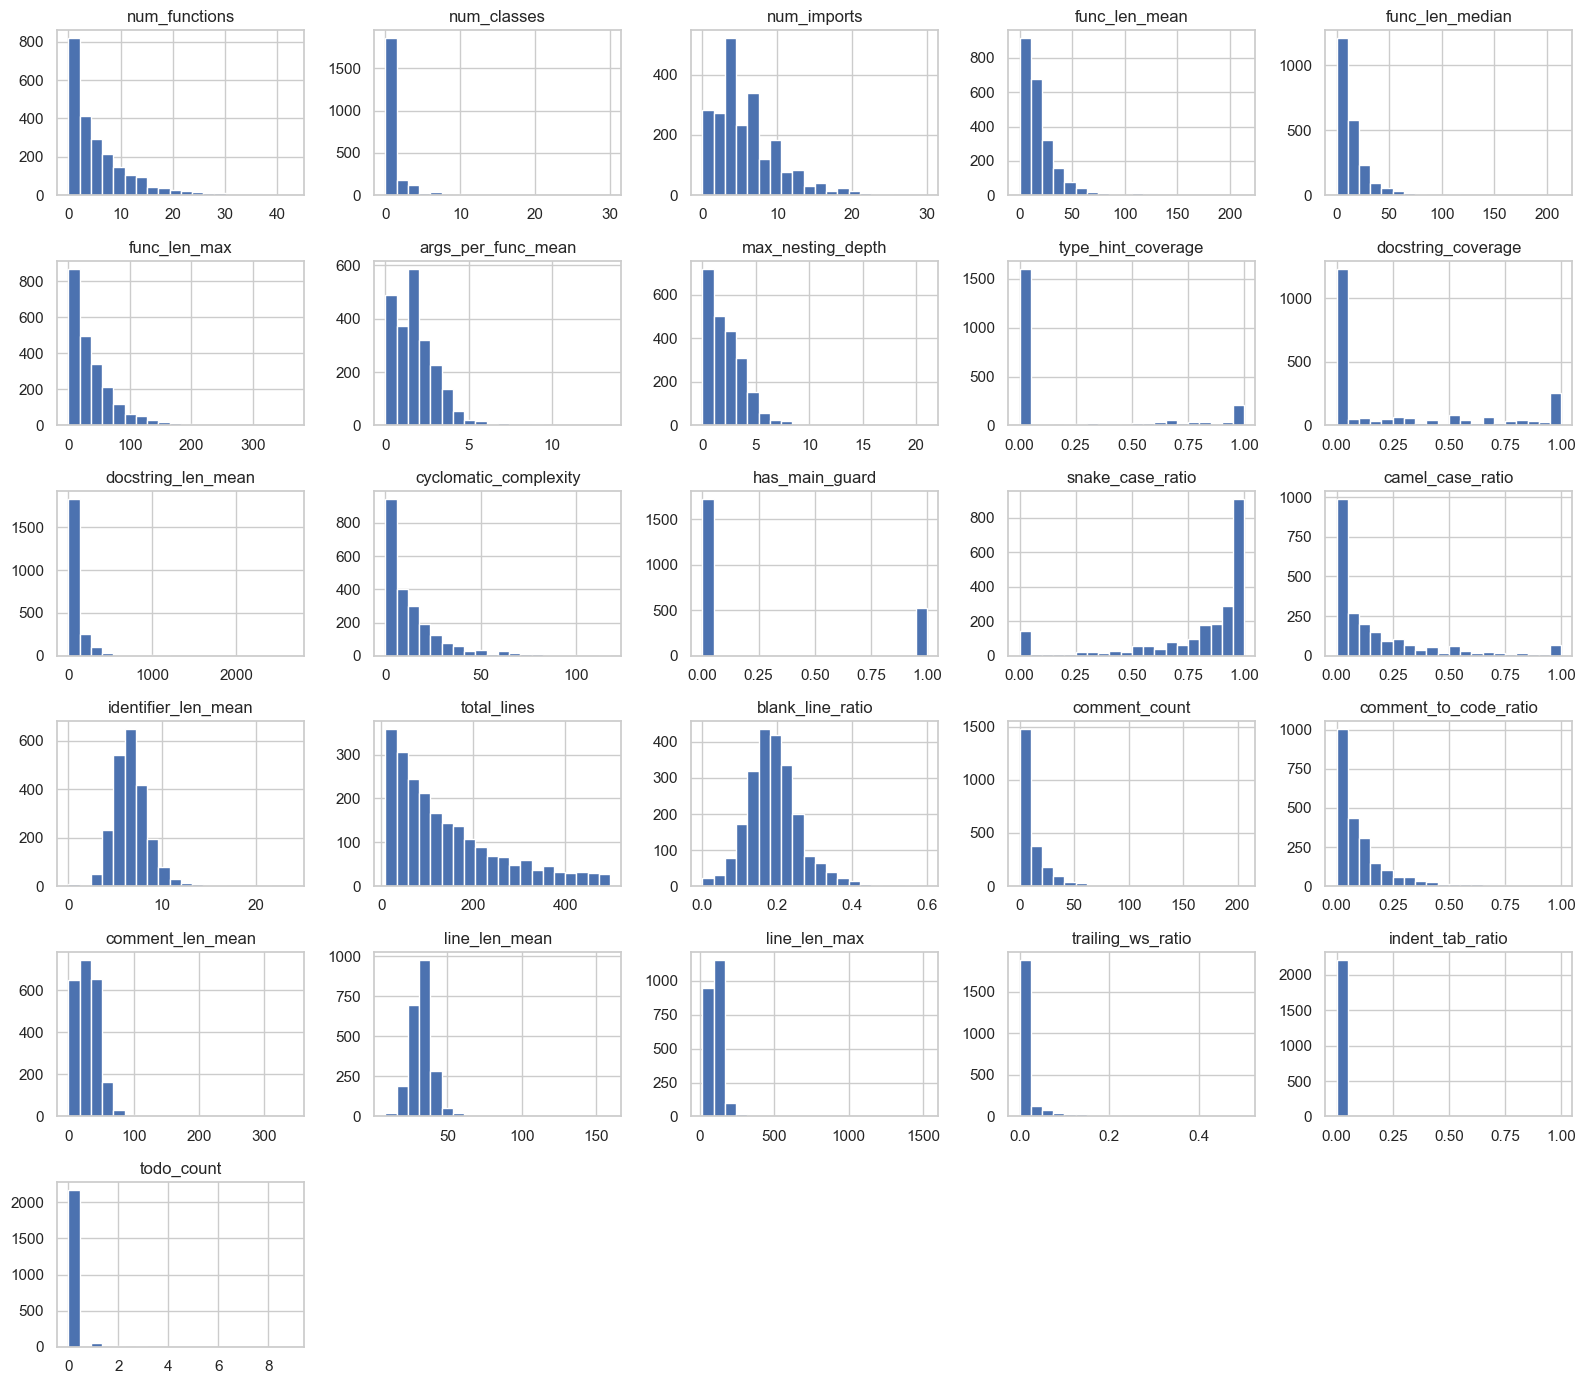

In [41]:
df[feature_cols].hist(figsize=(16, 14), bins=20)
plt.tight_layout()
plt.show()

In [42]:
human_df = df[df["label"] == "human"]
ai_df = df[df["label"] == "ai"]
rank = []
for col in feature_cols:
    h, a = human_df[col], ai_df[col]
    if h.nunique() <= 1 and a.nunique() <= 1:
        continue
    try:
        _, p = mannwhitneyu(h, a, alternative="two-sided")
    except ValueError:
        continue
    rank.append({"feature": col, "p_value": p})
rank_df = pd.DataFrame(rank).sort_values("p_value").reset_index(drop=True)
rank_df.head(15)

,feature,p_value
0,type_hint_coverage,1.116719e-149
1,comment_to_code_ratio,1.644983e-23
2,func_len_max,1.999706e-15
3,func_len_mean,1.617725e-14
4,line_len_max,2.137714e-14
5,cyclomatic_complexity,4.727560e-14
6,num_imports,5.746546e-13
7,func_len_median,1.951803e-10
8,identifier_len_mean,1.426805e-09
9,total_lines,3.744748e-09


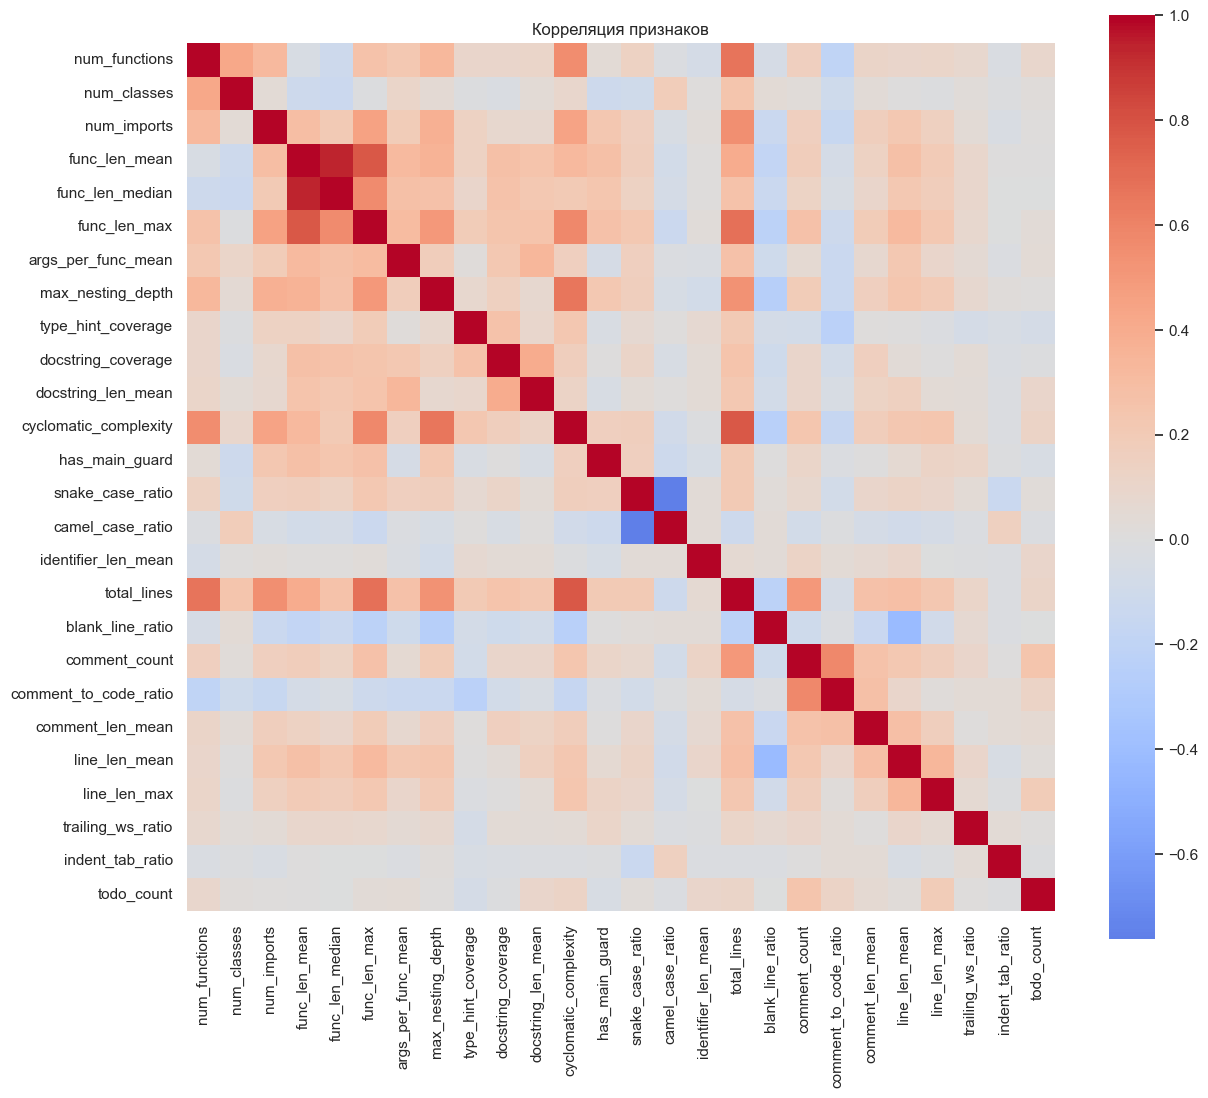

In [43]:
plt.figure(figsize=(14, 12))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, square=True)
plt.title("Корреляция признаков")
plt.show()

In [45]:
X = df[model_features].fillna(0.0)
y = (df["label"] == "ai").astype(int)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "logreg": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [200, 400], "max_depth": [None, 10, 20]},
    ),
    "xgboost": (
        XGBClassifier(random_state=RANDOM_STATE, cv=cv, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [3, 6], "learning_rate": [0.1, 0.3]},
    ),
}

rows, fitted = [], {}
for name, (estimator, grid) in models.items():
    search = GridSearchCV(estimator, grid, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    rows.append({
        "model": name,
        "cv_roc_auc": search.best_score_,
        "cv_std": search.cv_results_["std_test_score"][search.best_index_],
        "best_params": str(search.best_params_),
    })
results = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
best_name = results.loc[0, "model"]
best_model = fitted[best_name]
print("Лучшая модель:", best_name)
results

Лучшая модель: random_forest


,model,cv_roc_auc,cv_std,best_params
0,random_forest,0.898955,0.021465,"{'max_depth': 20, 'n_estimators': 400}"
1,xgboost,0.893660,0.020112,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
2,logreg,0.844358,0.023048,{'clf__C': 1.0}


=== random_forest ===
              precision    recall  f1-score   support

       human       0.78      0.89      0.83       227
          ai       0.87      0.75      0.80       223

    accuracy                           0.82       450
   macro avg       0.83      0.82      0.82       450
weighted avg       0.83      0.82      0.82       450

ROC-AUC: 0.913


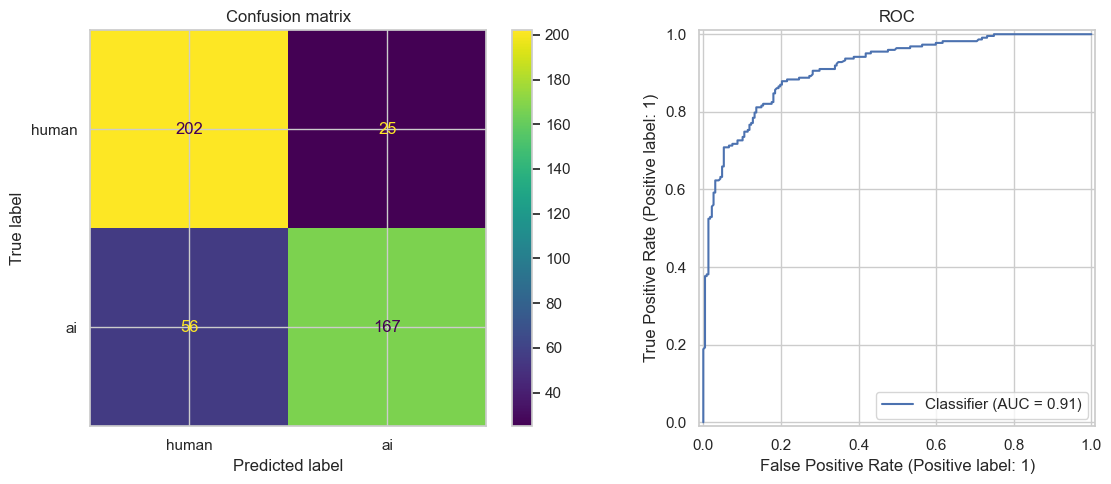

In [47]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report, roc_auc_score,
)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"=== {best_name} ===")
print(classification_report(y_test, y_pred, target_names=["human", "ai"]))
print(f"ROC-AUC: {auc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["human", "ai"], ax=axes[0])
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC")
plt.tight_layout()
plt.show()

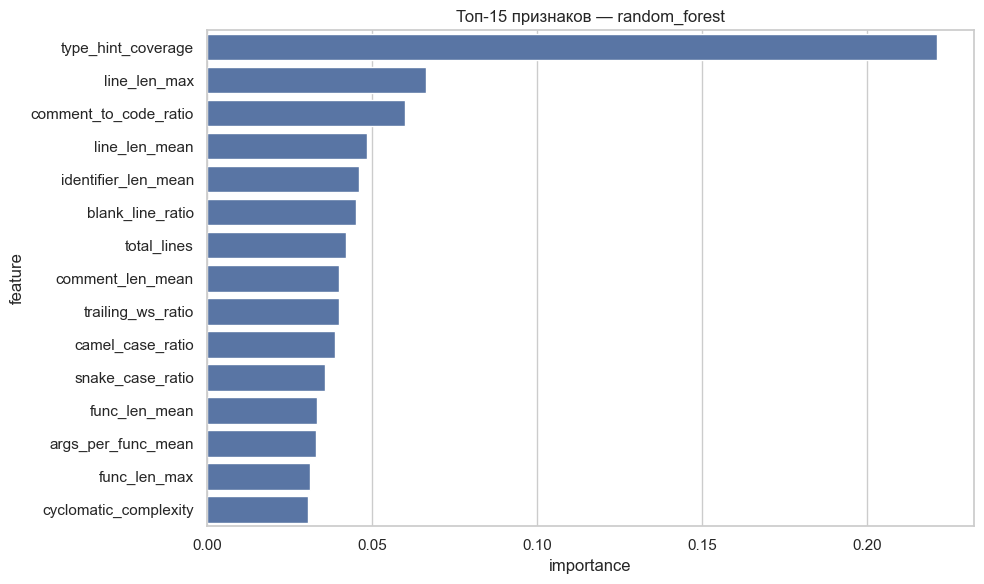

,feature,importance
8,type_hint_coverage,0.221327
22,line_len_max,0.066275
19,comment_to_code_ratio,0.059888
21,line_len_mean,0.048436
15,identifier_len_mean,0.045887
17,blank_line_ratio,0.045239
16,total_lines,0.042220
20,comment_len_mean,0.039860
23,trailing_ws_ratio,0.039855
14,camel_case_ratio,0.038794


In [49]:
imp = pd.DataFrame({"feature": model_features, "importance": best_model.feature_importances_})
imp = imp.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
top_imp = imp.head(15)
sns.barplot(data=top_imp, y="feature", x="importance")
plt.title(f"Топ-15 признаков — {best_name}")
plt.tight_layout()
plt.show()
top_imp